# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [65]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [84]:
# TODO: extract the dataset zip to an output folder
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'  # or your path
EXTRACT_DIR = 'heart_ds'
zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)
# Hint: use zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)

# TODO: list CSV files under EXTRACT_DIR
csv_path = 'heart_ds\\dataset_heart.csv'  # set to the CSV you choose

# TODO: load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)

# TODO: inspect df
display(df.head(15))
display(df.info())
display(df['heart disease'].value_counts())

#fixing typo
df['serum cholesterol'] = df['serum cholestoral']
df = df.drop(columns=['serum cholestoral'])
# TODO: identify target column
target = df['heart disease']  # 'heart disease'

# TODO: split features and target
X = df.drop(columns=['heart disease'])
y = df['heart disease']
# Using LabelEncoder to fix the encoding of y to 0, 1 rather than 1,2 to work with all models
le = LabelEncoder()
y = le.fit_transform(y)


# TODO: train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
# Hint: train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1
5,65,1,4,120,177,0,0,140,0,0.4,1,0,7,1
6,56,1,3,130,256,1,2,142,1,0.6,2,1,6,2
7,59,1,4,110,239,0,2,142,1,1.2,2,1,7,2
8,60,1,4,140,293,0,2,170,0,1.2,2,2,7,2
9,63,0,4,150,407,0,2,154,0,4.0,2,3,7,2


<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                            270 non-null    int64  
 11  major vessels                 

None

heart disease
1    150
2    120
Name: count, dtype: int64

### Basic visual checks

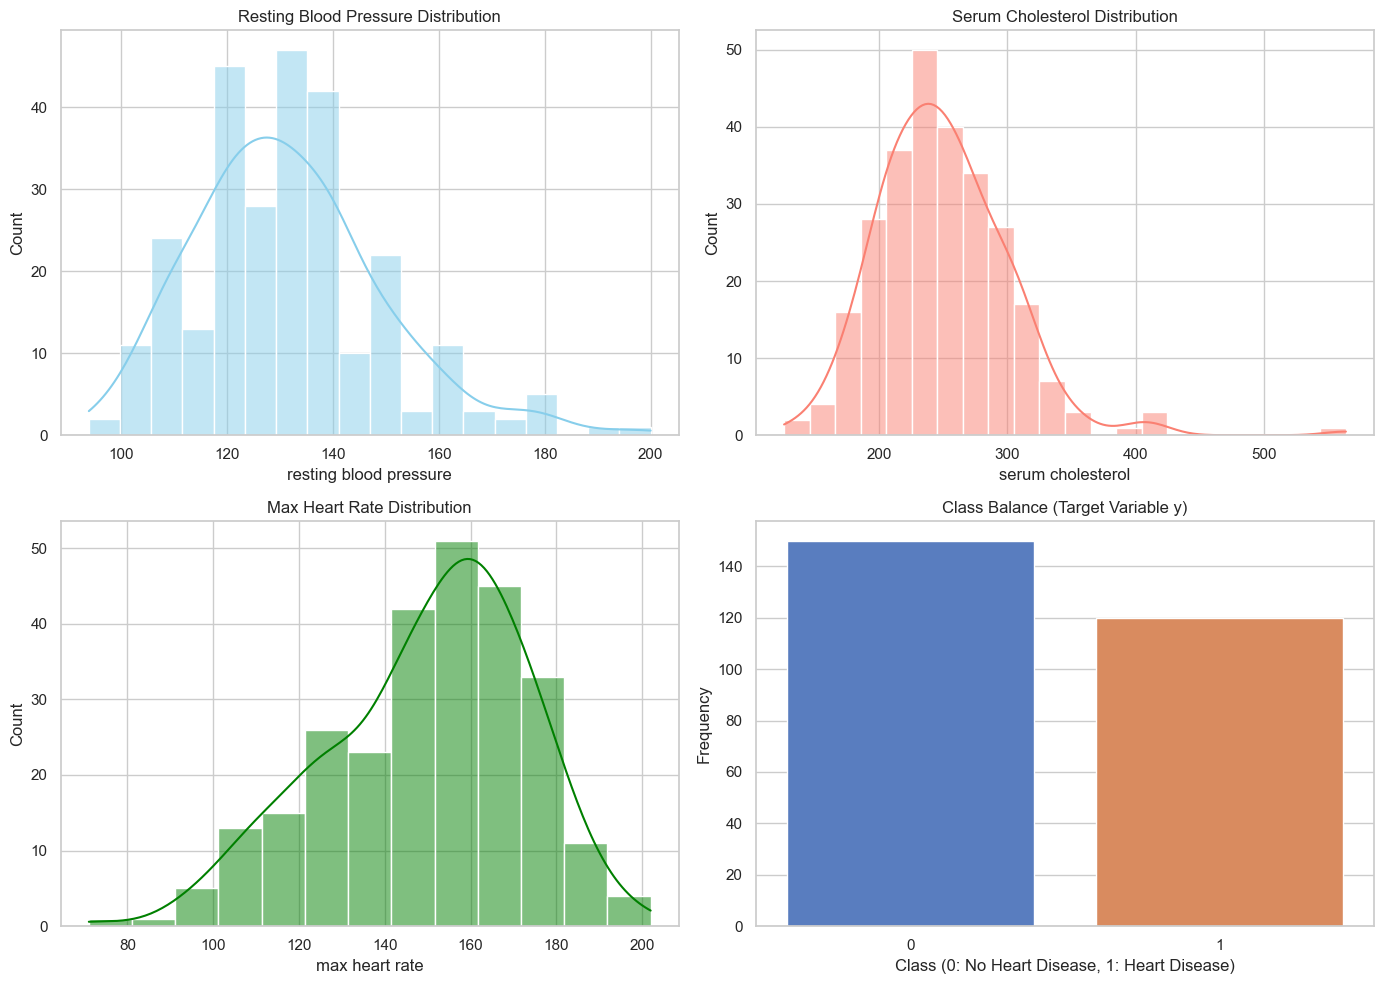

In [67]:
# TODO: pick a few numeric columns and plot histograms


# TODO: plot class balance as a bar chart

import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Initialize a 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram for Resting Blood Pressure
sns.histplot(X['resting blood pressure'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Resting Blood Pressure Distribution')

# 2. Histogram for Serum Cholesterol
sns.histplot(X['serum cholesterol'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Serum Cholesterol Distribution')

# 3. Histogram for Max Heart Rate
sns.histplot(X['max heart rate'], kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Max Heart Rate Distribution')

# 4. FIXED: Bar chart of class balance with hue assignment
y_counts = pd.Series(y).value_counts().sort_index()
sns.barplot(
    x=y_counts.index, 
    y=y_counts.values, 
    hue=y_counts.index,  # Assign x to hue
    ax=axes[1, 1], 
    palette='muted', 
    legend=False         # Disable redundant legend
)
axes[1, 1].set_title('Class Balance (Target Variable y)')
axes[1, 1].set_xlabel('Class (0: No Heart Disease, 1: Heart Disease)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Preprocessing pipeline

In [68]:
cat_cols = X.select_dtypes(include=['object', 'category', 'bool', 'string']).columns.tolist() # list of object, category, or bool columns
num_cols = X.select_dtypes(include=['number']).columns.tolist() # list of numeric columns


# TODO: build a ColumnTransformer named pre
pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])



## Helper - evaluation function

In [69]:
def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # TODO: predictions
    y_pred = model.predict(X_test)  # model.predict(...)

    # TODO: compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }
    print(name, metrics)

    # TODO: confusion matrix plot
    # Hint: confusion_matrix(y_test, y_pred)
    # Draw with plt.imshow or ConfusionMatrixDisplay
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

    # TODO: ROC curve if model has predict_proba
    # 1. Get predicted probabilities for the positive class (class 2)
    # model.predict_proba returns [prob_class_1, prob_class_2]
    y_probs = model.predict_proba(X_test)[:, 1]

    # 2. Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_probs, pos_label=1)
    auc_score = roc_auc_score(y_test, y_probs)

    # 3. Plot the ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal random guess line

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Receiver Operating Characteristic (ROC) - Heart Disease Prediction')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    return metrics


## Exercise 2 - Logistic Regression without Grid Search

Logistic Regression without Grid Search {'accuracy': 0.8518518518518519, 'precision': 0.7857142857142857, 'recall': 0.9166666666666666, 'f1': 0.8461538461538461}


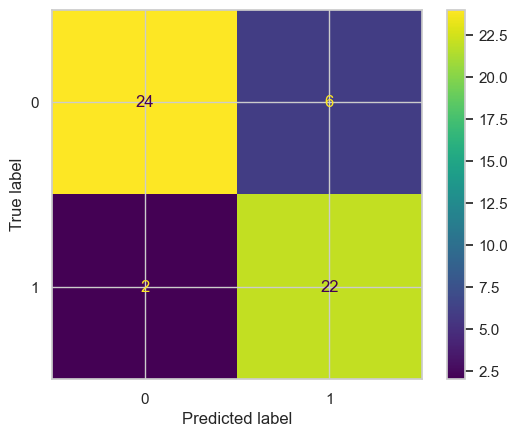

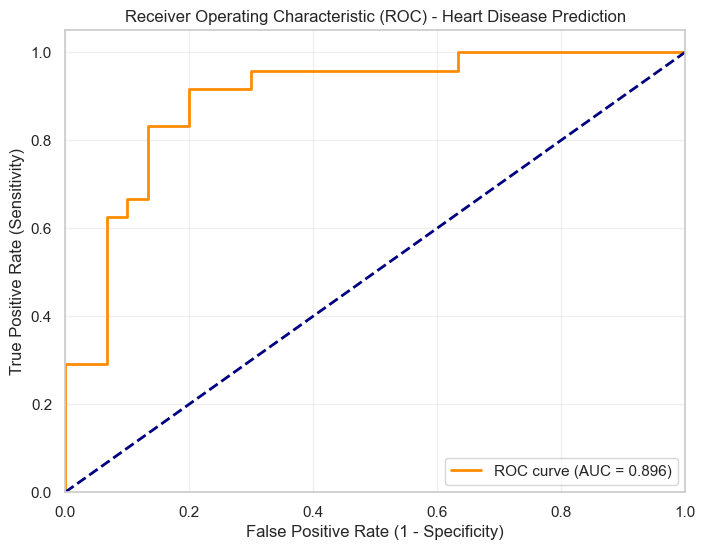

In [70]:
# TODO: create a Pipeline with your preprocessor and LogisticRegression
# Hint: solver 'liblinear' is fine, increase max_iter if needed
pipe_lr = Pipeline([
    ('preprocessor', pre),
    ('lr', LogisticRegression(
        solver='liblinear', 
        max_iter=1000, 
        class_weight='balanced', 
        random_state=42
    ))
])

# TODO: fit on training data
# pipe_lr.fit(...)
pipe_lr.fit(X_train, y_train)

# TODO: evaluate with eval_and_report

lr_no_gs_metrics = eval_and_report('Logistic Regression without Grid Search', pipe_lr, X_test, y_test)


## Exercise 3 - Logistic Regression with Grid Search

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'lr__C': 0.001, 'lr__l1_ratio': 0}
LR grid {'accuracy': 0.8333333333333334, 'precision': 0.7777777777777778, 'recall': 0.875, 'f1': 0.8235294117647058}


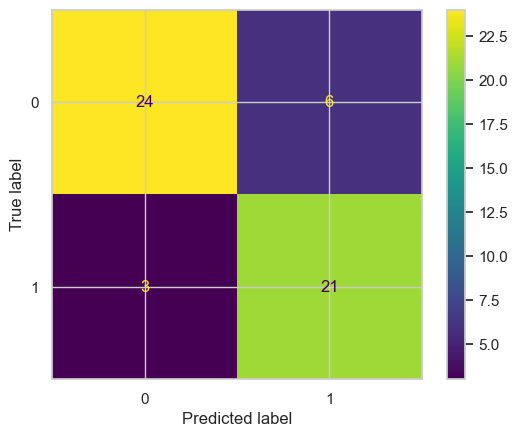

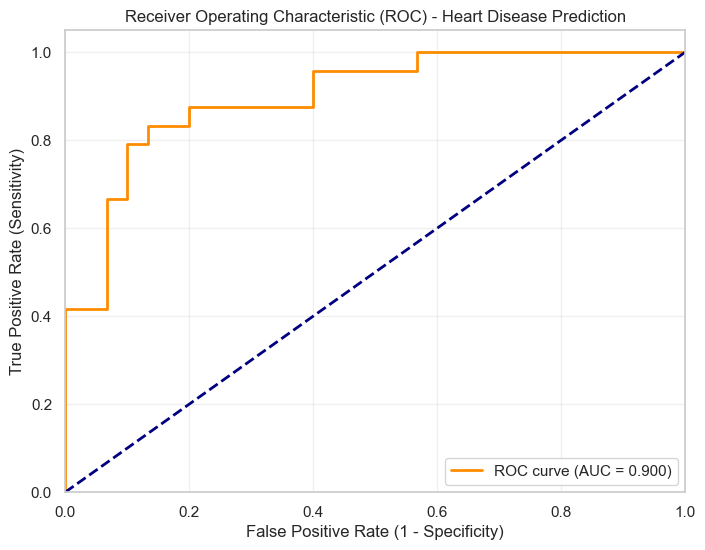

In [71]:
# TODO: build a Pipeline same as above
pipe_lr_cv = Pipeline([
    ('preprocessor', pre),
    ('lr', LogisticRegression(
        solver='liblinear', 
        max_iter=1000, 
        class_weight='balanced', 
        random_state=42
    ))
])
# TODO: define param_grid for lr__C and lr__penalty
# Hint: use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {
     'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
#     'lr__penalty': ['l1', 'l2'],
# Per error message that 'penalty' was deprecated, using 'ratio' instead.
    'lr__l1_ratio': [1,0]
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1', verbose=1)
grid_lr.fit(X_train, y_train)
# grid_lr.fit(...)
print('Best params:', grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)


## Exercise 4 - SVM without Grid Search

SVM no grid {'accuracy': 0.8148148148148148, 'precision': 0.7692307692307693, 'recall': 0.8333333333333334, 'f1': 0.8}


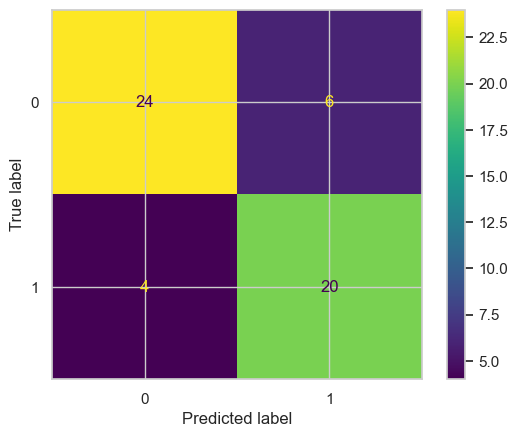

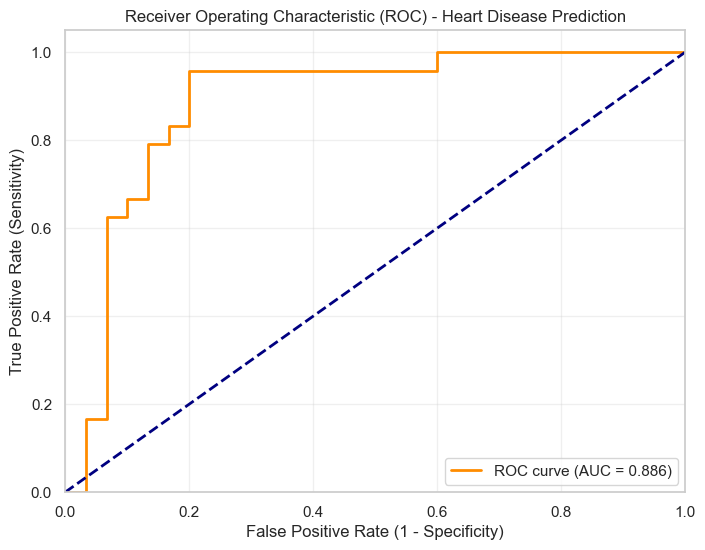

In [72]:
# TODO: choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' with C=1.0 and gamma='scale'
pipe_svm = Pipeline([
    ('preprocessor', pre),
    ('svm', SVC(
        kernel='rbf',
        probability=True, 
        C=1.0, 
        gamma='scale', 
        random_state=42
    ))
])
# pipe_svm.fit(...)
pipe_svm.fit(X_train, y_train)
# svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)
svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)

## Exercise 5 - SVM with Grid Search

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
SVM grid {'accuracy': 0.8518518518518519, 'precision': 0.8076923076923077, 'recall': 0.875, 'f1': 0.84}


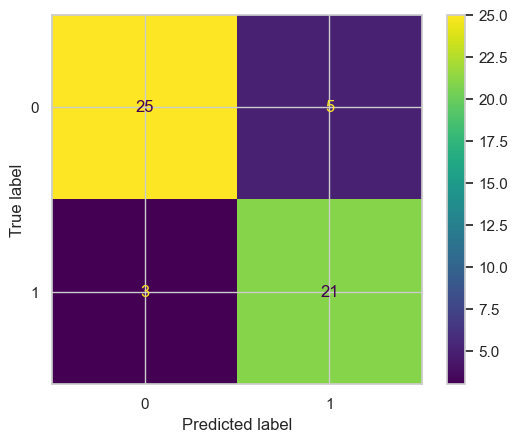

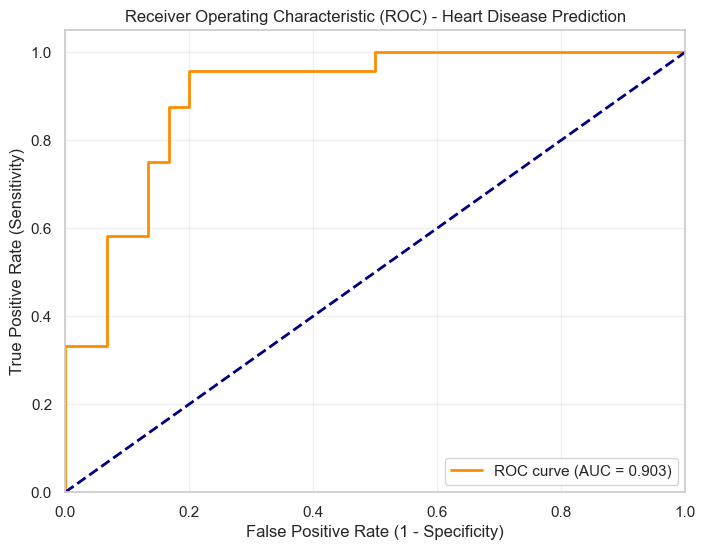

In [73]:
# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline([
    ('preprocessor', pre),
    ('svm', SVC(
        kernel='rbf',
        probability=True, 
        C=1.0, 
        gamma='scale', 
        random_state=42
    ))
])

# TODO: param_grid with svm__kernel, svm__C, svm__gamma

svm_param_grid = {
     'svm__kernel': ['rbf','linear'],
     'svm__C': [0.1,1,10,100],
     'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    # 'svm__kernel': ['rbf','linear'],
    # 'svm__C': [...],
    # 'svm__gamma': ['scale','auto', ...],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring='f1', verbose=1)
grid_svm.fit(X_train, y_train)
print('Best params:', grid_svm.best_params_)
best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)
# best_svm = grid_svm.best_estimator_
# svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)


## Exercise 6 - XGBoost without Grid Search

XGB no grid {'accuracy': 0.7962962962962963, 'precision': 0.7407407407407407, 'recall': 0.8333333333333334, 'f1': 0.7843137254901961}


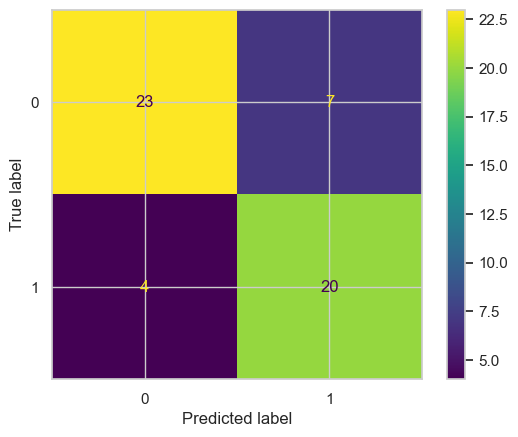

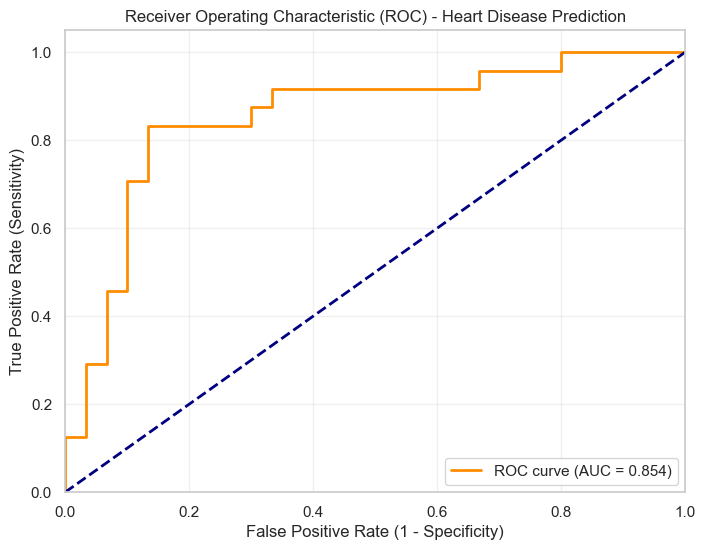

In [82]:
# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
# Hint: start with n_estimators around 300, learning_rate 0.1, max_depth 3 to 5
pipe_xgb = Pipeline([
    ('preprocessor', pre),
    ('xgb', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1, 
        max_depth=3, 
        random_state=42
    ))
])
# I used the suggested hyperparameters. This is a conservative, robust configuration that prioritizes generalization over raw complexity. In the context of clinical data (like this heart disease dataset), this setup helps prevent the model from "memorizing" specific patients and instead forces it to learn broader medical patterns.
# Because the learning_rate is relatively low (0.1) and the max_depth is shallow (3), the model needs a higher number of trees (300) to fully map out the underlying patterns in the data. These parameters work in a trade-off: as you decrease the learning rate, you generally must increase the number of estimators to reach the same level of accuracy.

# pipe_xgb.fit(...)
# xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)
pipe_xgb.fit(X_train, y_train)
xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)


## Exercise 7 - XGBoost with Grid Search

Fitting 5 folds for each of 72 candidates, totalling 360 fits
XGB grid {'accuracy': 0.8333333333333334, 'precision': 0.8, 'recall': 0.8333333333333334, 'f1': 0.8163265306122449}


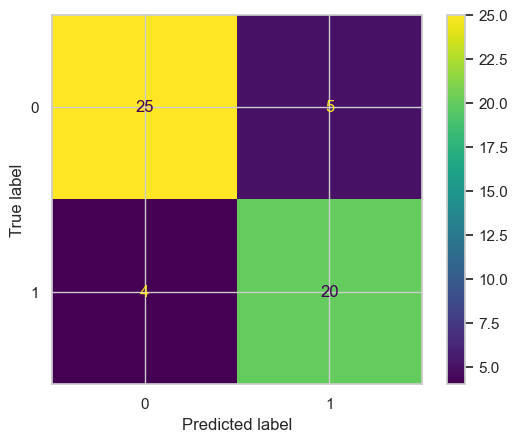

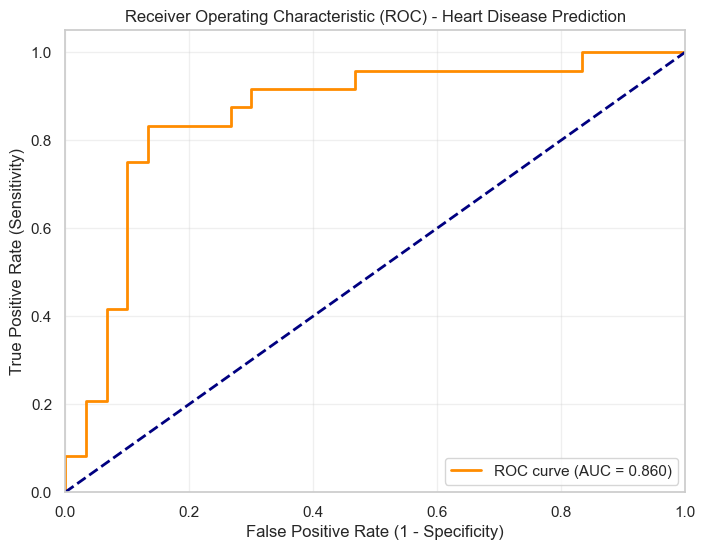

In [78]:
# TODO: Pipeline with XGBClassifier
pipe_xgb_cv = Pipeline([
    ('preprocessor', pre),
    ('xgb', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1, 
        max_depth=3, 
        random_state=42
    ))
])

# TODO: define a reasonable param_grid
xgb_param_grid = {
'xgb__n_estimators': [100, 200],           # Number of trees
    'xgb__learning_rate': [0.01, 0.1, 0.2],    # Step size shrinkage (eta)
    'xgb__max_depth': [3, 5, 7],               # Depth of each tree
    'xgb__subsample': [0.8, 1.0],              # % of samples used per tree
    'xgb__colsample_bytree': [0.8, 1.0]        # % of features used per tree
    # 
    # 'xgb__n_estimators': [...],
    # 'xgb__learning_rate': [...],
    # 'xgb__max_depth': [...],
    # 'xgb__subsample': [...],
    # 'xgb__colsample_bytree': [...],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(pipe_xgb_cv, xgb_param_grid, cv=5, scoring='f1', verbose=1)
# best_xgb = grid_xgb.best_estimator_
# xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)

grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_
xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)

## Compare models

In [83]:
# TODO: build a comparison DataFrame from your metrics dicts
# Hint: pd.DataFrame.from_dict(metrics, orient='index')

summary = {}
# summary['LR no grid'] = lr_no_gs_metrics
summary['LR no Grid Search'] = lr_no_gs_metrics
summary['LR Grid Search'] = lr_gs_metrics
summary['SVM no Grid Search'] = svm_no_metrics
summary['SVM Grid Search'] = svm_gs_metrics
summary['XGB no Grid Search'] = xgb_no_metrics
summary['XGB Grid Search'] = svm_gs_metrics
# ... add others you computed ...

summary_df = pd.DataFrame.from_dict(summary, orient='index')
summary_df


,accuracy,precision,recall,f1
LR no Grid Search,0.851852,0.785714,0.916667,0.846154
LR Grid Search,0.833333,0.777778,0.875000,0.823529
SVM no Grid Search,0.814815,0.769231,0.833333,0.800000
SVM Grid Search,0.851852,0.807692,0.875000,0.840000
XGB no Grid Search,0.796296,0.740741,0.833333,0.784314
XGB Grid Search,0.851852,0.807692,0.875000,0.840000


Conclusion: These results are interesting. Despite everything, LR without Grid Search shows very impressive results. Given that in the case of predicting heart disease there is a high cost to missing a diseased patient, we would prefer to have a higher recall. Thus LR without Grid Search shows the highest recall and might be the preferred model. However, the test set is pretty small and we might want to try this again with different training and test sets before making a final decision for which model to use in a clinical setting.